## <strong>9. RESTful API를 이용한 데이터 취득</strong>

In [2]:
pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.3 MB 10.4 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 11.7 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 12.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 11.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 13.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   --------------- ------------------------ 2.9/7.2 MB 14.2 MB/s eta 0:00:01
   ------------------------------- -------- 5.8/7.2 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 13.0 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import requests  # HTTP 통신 라이브러리
import matplotlib.pyplot as plt #a 데이터 시각화
import time # API 요청 제한(Rate Limit) 우회를 위한 시간 제어

In [4]:
# 1. 상위 100개 코인 정보 가져오기 (Data Acquisition 단계)
def get_top_100_coins():
    """
    CoinGecko API를 통해 시장의 원천 데이터(Raw Data)를 취득
    """
    url = "https://api.coingecko.com/api/v3/coins/markets"
    
    # API 요청 파라미터 설정
    params = {
        "vs_currency": "usd",        # 통화 단위: USD
        "order": "market_cap_desc",  # 정렬 기준: 시가총액 내림차순
        "per_page": 100,             # 취득할 데이터 양: 100개
        "page": 1,                   # 페이지 번호
        "sparkline": False           # 데이터 부하를 줄이기 위해 그래프 데이터 제외
    }
    
    # RESTful API 호출 (HTTP GET 방식)
    response = requests.get(url, params=params)
    
    # 응답받은 JSON 데이터를 파이썬 객체로 변환
    return response.json()

In [5]:
# 2. 특정 코인의 시가총액 추이 가져오기
def get_market_chart(coin_id):
    """
    특정 코인의 ID를 사용하여 시계열 데이터를 요청
    """
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        "vs_currency": "usd",
        "days": 365,          # 데이터 범위: 최근 365일
        "interval": "daily"   # 데이터 간격: 일 단위 (데이터 정제 과정)
    }
    
    response = requests.get(url, params=params)
    
    # HTTP 상태 코드가 200(성공)일 경우에만 데이터 반환 (예외 처리)
    if response.status_code == 200:
        return response.json()["market_caps"]
    else:
        # 데이터 취득 실패 시 빈 리스트 반환
        return []

In [6]:
# 3. 시각화 함수 
def plot_market_caps(coin_data):
    """
    가공된 데이터를 바탕으로 분석용 차트를 생성
    """
    plt.figure(figsize=(16, 10))

    for coin_name, market_caps in coin_data.items():
        if not market_caps:
            continue
            
        timestamps = [cap[0] for cap in market_caps] # x축: 타임스탬프
        
        # 데이터 스케일링: 가독성을 위해 달러 단위를 10억(Billion) 단위로 변환
        values = [cap[1] / 1e9 for cap in market_caps] 
        
        plt.plot(timestamps, values, label=coin_name)

    # 시각화
    plt.title("Top 100 Alt Coins - Market Cap Trend (Last 365 Days)")
    plt.xlabel("Timestamp")
    plt.ylabel("Market Cap (Billion USD)")
    plt.xticks(rotation=45)
    plt.legend(fontsize="small", loc="upper left", ncol=2)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [7]:
# --- 메인 실행 흐름 ---

print("🚀 상위 100개 코인 정보를 불러오는 중...")
all_coins = get_top_100_coins()

# 데이터 필터링: 시장 지배력이 너무 큰 BTC, ETH를 제외하여 주요 알트코인들의 추이를 비교
coins = all_coins[2:] 

coin_market_data = {}

# 반복문을 통한 대량 데이터 취득
for i, coin in enumerate(coins):
    coin_id = coin["id"]
    coin_name = coin["name"]
    
    print(f"📈 데이터 수집 중: {coin_name} ({i+1}/100)")
    market_caps = get_market_chart(coin_id)
    
    # 딕셔너리에 데이터 적재
    coin_market_data[coin_name] = market_caps
    
    # API 요청 제한 우회
    time.sleep(1.2) 

    # 실습 효율을 위해 상위 4개 알트코인만 수집 후 중단
    if i >= 3: 
        break

🚀 상위 100개 코인 정보를 불러오는 중...
📈 데이터 수집 중: Tether (1/100)
📈 데이터 수집 중: XRP (2/100)
📈 데이터 수집 중: BNB (3/100)
📈 데이터 수집 중: USDC (4/100)


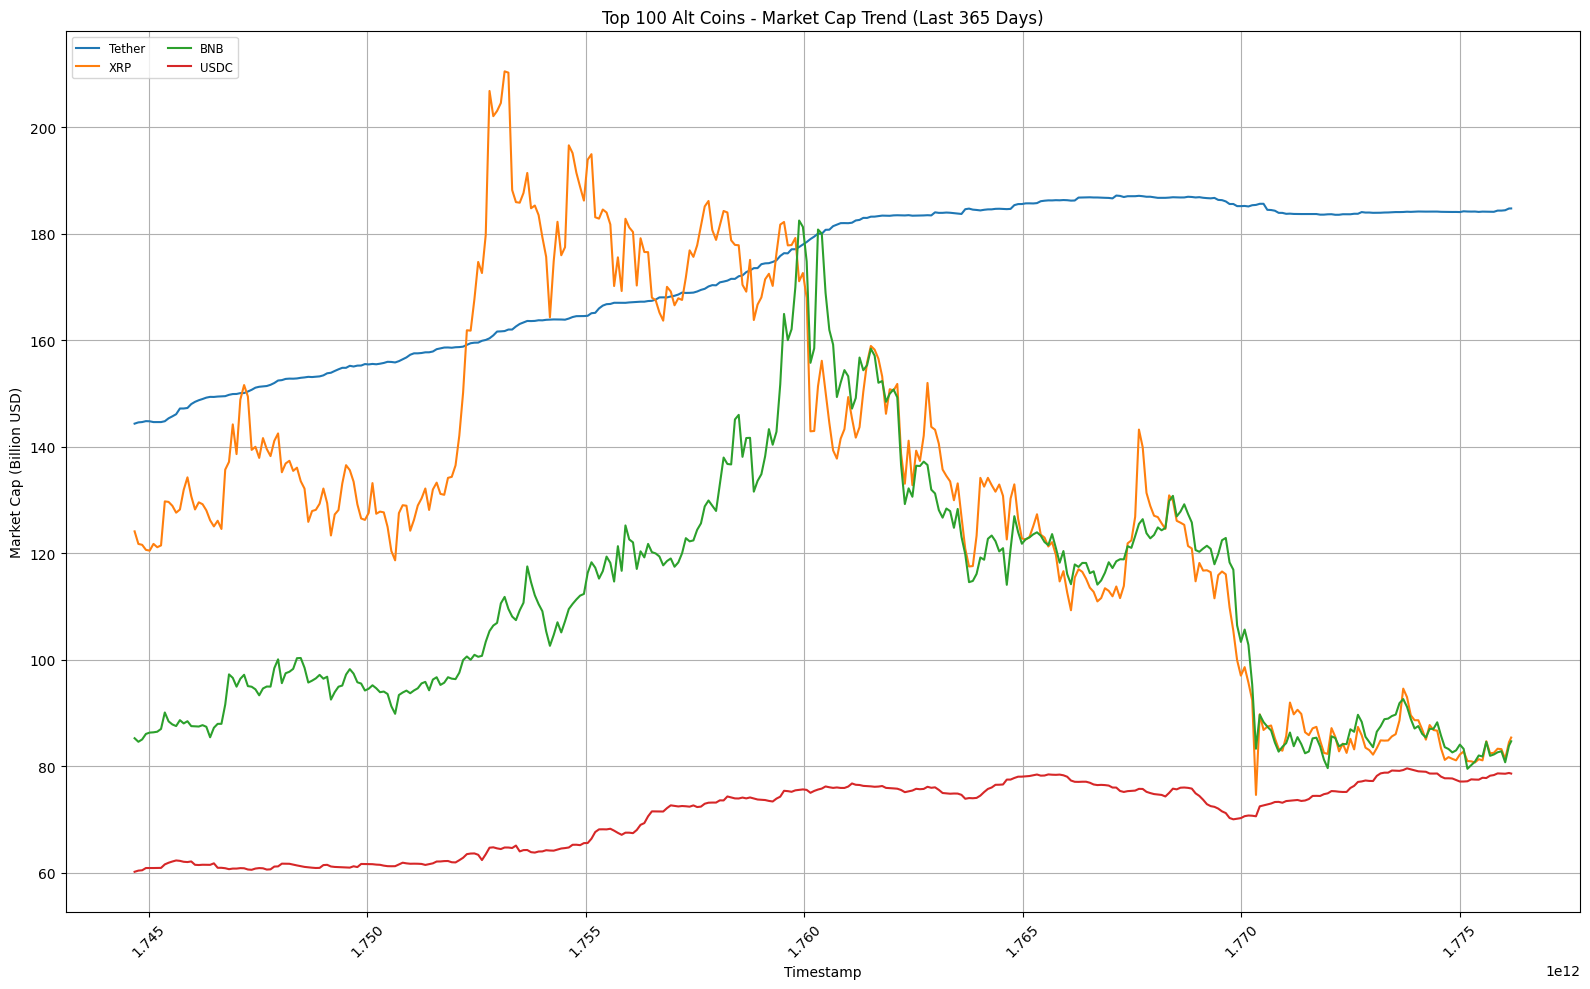

In [8]:
# 최종 가공된 데이터를 시각화
plot_market_caps(coin_market_data)

In [9]:
# get_top_100_coins() 응답 내용(JSON) 확인
coins

[{'id': 'tether',
  'symbol': 'usdt',
  'name': 'Tether',
  'image': 'https://coin-images.coingecko.com/coins/images/325/large/Tether.png?1696501661',
  'current_price': 1.0,
  'market_cap': 184735273804,
  'market_cap_rank': 3,
  'fully_diluted_valuation': 190204014828,
  'total_volume': 97147043284,
  'high_24h': 1.0,
  'low_24h': 1.0,
  'price_change_24h': 0.00020735,
  'price_change_percentage_24h': 0.02073,
  'market_cap_change_24h': 275111896,
  'market_cap_change_percentage_24h': 0.14914,
  'circulating_supply': 184674430497.4122,
  'total_supply': 190141370368.7762,
  'max_supply': None,
  'ath': 1.32,
  'ath_change_percentage': -24.39645,
  'ath_date': '2018-07-24T00:00:00.000Z',
  'atl': 0.572521,
  'atl_change_percentage': 74.7197,
  'atl_date': '2015-03-02T00:00:00.000Z',
  'roi': None,
  'last_updated': '2026-04-14T14:03:53.917Z'},
 {'id': 'ripple',
  'symbol': 'xrp',
  'name': 'XRP',
  'image': 'https://coin-images.coingecko.com/coins/images/44/large/xrp-symbol-white-128.

In [10]:
# get_market_chart() 응답 내용(JSON) 확인
market_caps

[[1744675200000, 60199908506.245766],
 [1744761600000, 60417188776.17674],
 [1744848000000, 60482834985.68738],
 [1744934400000, 60905068137.7922],
 [1745020800000, 60899531624.784546],
 [1745107200000, 60905279546.47661],
 [1745193600000, 60912555306.20599],
 [1745280000000, 60928832833.85901],
 [1745366400000, 61589269101.35528],
 [1745452800000, 61896921299.12466],
 [1745539200000, 62129850660.586266],
 [1745625600000, 62325968054.99818],
 [1745712000000, 62251662906.80433],
 [1745798400000, 62076749988.76833],
 [1745884800000, 62026261648.921],
 [1745971200000, 62142665088.87474],
 [1746057600000, 61508869555.16433],
 [1746144000000, 61469063386.18792],
 [1746230400000, 61520122153.8279],
 [1746316800000, 61504588129.61178],
 [1746403200000, 61502292587.1267],
 [1746489600000, 61786628299.92093],
 [1746576000000, 60949351180.20576],
 [1746662400000, 60947364928.44116],
 [1746748800000, 60867341067.19171],
 [1746835200000, 60689997043.40309],
 [1746921600000, 60800003218.424],
 [174